# Tarea: 

Buscar y configurar el análisis exploratorio de datos en un solo dashboard 

# 06_analisis_exploratorio

Proyecto ARIMA / ARIMAX
Modelación epidemiológica con variables meteorológicas.

# Inicio del análisis


Para esta **etapa de análisis exploratorio (EDA)** en el estudio del comportamiento del dengue en Caucasia con relación a variables meteorológicas, seguiremos una estructura de un **mini–diagnóstico epidemiológico y climático de la serie temporal**. 




# 1. Verificación estructural de la base

Primero asegúrate de que la serie es consistente.

Objetivos:

* Semanas consecutivas
* Sin duplicados
* Sin huecos


# Lectura y conversión a dataframe del dataset fusionado 

In [1]:
import pandas as pd 

path_janis = r"C:\Users\usuario1\Documents\GitHub\arima\1_programa_trabajo\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\datos_fusionados_semanales.xlsx"
path_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\3_base_datos_consolidada\datos_fusionados_semanales.xlsx"
df_fusionado = pd.read_excel(path_marco)
# hacer que fecha sea el indice y sea de tipo datetime
df_fusionado['fecha'] = pd.to_datetime(df_fusionado['fecha']) # convertir en tipo datetime
df_fusionado.set_index('fecha', inplace=True)  # hacer que fecha sea el indice 
df_fusionado.head()

,año,semana_epidemiologica,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,casos_dengue
fecha,,,,,,,,,,,,,,
2021-01-03,2021,1,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857,0
2021-01-10,2021,2,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286,0
2021-01-17,2021,3,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000,1
2021-01-24,2021,4,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143,0
2021-01-31,2021,5,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,0.221429,0.030000,2.290000,0


# Visualización tabular 

In [2]:
df_fusionado.info() # Determinar la naturaleza de las variables 


<class 'pandas.DataFrame'>
DatetimeIndex: 261 entries, 2021-01-03 to 2025-12-28
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   año                    261 non-null    int64  
 1   semana_epidemiologica  261 non-null    int64  
 2   temp                   261 non-null    float64
 3   temp_max               261 non-null    float64
 4   temp_min               261 non-null    float64
 5   hum_esp                261 non-null    float64
 6   hum_rel                261 non-null    float64
 7   prec                   261 non-null    float64
 8   dias_lluvia            261 non-null    int64  
 9   vel_vi                 261 non-null    float64
 10  vel_vi_max             261 non-null    float64
 11  vel_vi_min             261 non-null    float64
 12  uv                     261 non-null    float64
 13  casos_dengue           261 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 30.6 KB


# Tarea: redactar la interpretación de esta tabla para el trabajo de grado y el artículo 

In [3]:
df_fusionado.describe().round(1) # medidas de tendencia central y de dispersión (desviación estándar y el rango)



,año,semana_epidemiologica,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,casos_dengue
count,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0,261.0
mean,2023.0,26.6,27.4,31.3,24.4,18.7,83.1,32.4,4.4,0.1,0.3,0.0,2.2,23.4
std,1.4,15.1,1.5,2.8,0.8,1.5,10.5,28.4,2.3,0.0,0.1,0.0,0.2,23.1
min,2021.0,1.0,25.1,27.6,21.8,15.0,55.9,0.0,0.0,0.1,0.2,0.0,1.7,0.0
25%,2022.0,14.0,26.2,29.1,23.9,17.5,74.5,11.3,2.0,0.1,0.3,0.0,2.0,7.0
50%,2023.0,27.0,27.0,30.2,24.4,19.1,88.9,26.7,5.0,0.1,0.3,0.0,2.2,16.0
75%,2024.0,40.0,28.3,33.5,24.9,19.9,91.5,44.6,6.0,0.2,0.4,0.0,2.3,32.0
max,2025.0,53.0,32.7,39.0,27.7,21.1,94.1,160.4,7.0,0.2,0.5,0.1,2.7,106.0


# Tarea: redactar la interpretación de esta tabla para el trabajo de grado y el artículo 


# Verificar continuidad temporal:




Revisar faltantes:



In [4]:
df_fusionado.isna().sum()


año                      0
semana_epidemiologica    0
temp                     0
temp_max                 0
temp_min                 0
hum_esp                  0
hum_rel                  0
prec                     0
dias_lluvia              0
vel_vi                   0
vel_vi_max               0
vel_vi_min               0
uv                       0
casos_dengue             0
dtype: int64


# 2. Evolución temporal de los casos de dengue

Esto permite ver:

* brotes
* estacionalidad
* tendencias



# Visualización gráfica 

Tarea: estructurar la secuencia de visualización   

Cuando trabajas con **datos meteorológicos y epidemiológicos**, la visualización debe seguir una **secuencia estructurada** que vaya desde la comprensión básica hasta el análisis de relaciones complejas. Aquí tienes un esquema sólido, pensado tanto para investigación como para docencia:

---



# Secuencia estructurada de visualización de datos

## 1. Comprensión del problema (enfoque analítico)

Antes de graficar, define:

* ¿Qué fenómeno epidemiológico estudias? (ej. dengue, COVID-19)
* ¿Qué variables meteorológicas tienes? (temperatura, humedad, lluvia)
* ¿Qué relación esperas?

- Ejemplo:

> ¿La precipitación influye en el aumento de casos de dengue?

---



## 2. Preparación e integración de datos

* Unificar fuentes (IDEAM + datos de salud)
* Alinear por:

  * Fecha
  * Ubicación
* Manejar:

  * Valores faltantes
  * Outliers

- Resultado: un único `DataFrame`

---



## 3. Visualización univariada (entender cada variable)

### Meteorológicos

* Temperatura → histograma
* Precipitación → boxplot

### Epidemiológicos

* Casos → serie de tiempo
* Tasas → histogramas

- Pregunta clave:

> ¿Cómo se distribuyen los datos?

---



## 4. Visualización temporal (clave en tu caso)

Aquí está el corazón del análisis:

* Series de tiempo:

  * Casos vs tiempo
  * Temperatura vs tiempo
  * Lluvia vs tiempo

- Superposición:

* Casos + precipitación
* Casos + temperatura

- Pregunta:

> ¿Hay patrones sincronizados o rezagos?

---



## 5. Análisis de relaciones (bivariado)

* Scatter plots:

  * lluvia vs casos
  * temperatura vs casos

* Correlación:

  * matriz de correlación

- Pregunta:

> ¿Existe relación entre clima y enfermedad?

---



## 6. Análisis con rezagos (muy importante)

En epidemiología ambiental:

* La lluvia NO afecta inmediatamente
* Puede haber retrasos (lags)

 Ejemplo:

* lluvia (t) vs casos (t + 7 días)

Visualiza:

* curvas desplazadas
* correlación con rezagos

- Pregunta:

> ¿El clima predice brotes futuros?

---



## 🔹 7. Segmentación espacial (si tienes ubicación)

* Mapas:

  * casos por región
  * temperatura por zona

- Pregunta:

> ¿Dónde ocurre el fenómeno?

---



## 8. Síntesis en dashboard

Aquí integras todo:

* KPIs:

  * total de casos
  * promedio de temperatura

* Gráficos clave:

  * serie temporal
  * scatter con correlación
  * histograma

* Filtros:

  * fecha
  * región

- Puedes usar:

* Dash
* Plotly

---



## 9. Interpretación (nivel científico)

Aquí ocurre el verdadero análisis:

* Identificar patrones:

  * estacionalidad
  * picos
* Evaluar:

  * correlación ≠ causalidad
* Formular hipótesis

---



## 🔹 10. Comunicación de resultados

* Gráficos simples y claros
* Narrativa:

  1. Qué se observó
  2. Qué significa
  3. Qué implicaciones tiene

---



# Esquema mental resumido

```
Datos → Limpieza → Univariado → Temporal → Relaciones → Rezagos → Espacial → Dashboard → Interpretación
```

---



# En tu contexto docente (muy potente)

Puedes estructurar una clase así:

1. Estudiantes exploran variables (EDA)
2. Detectan patrones
3. Construyen visualizaciones
4. Integran en dashboard
5. Interpretan resultados

- Esto conecta con:

* pensamiento computacional
* modelación
* análisis de datos reales

---



# Idea avanzada (para investigación o clase)

Plantea como problema:

> “Construya un sistema visual que permita anticipar brotes epidemiológicos a partir de variables meteorológicas”

Esto integra:

* series de tiempo
* correlación
* visualización
* toma de decisiones

---


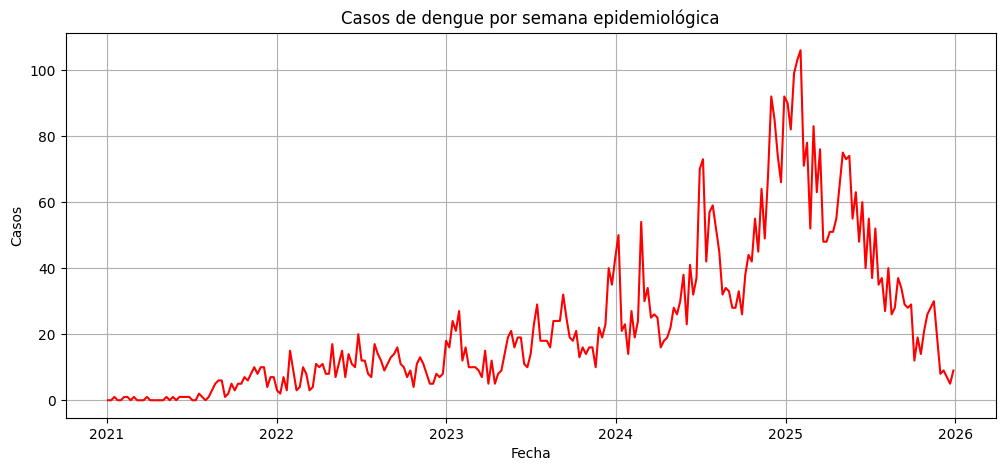

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_fusionado.index, df_fusionado["casos_dengue"], color="red", marker="", linestyle="-")

plt.title("Casos de dengue por semana epidemiológica")
plt.xlabel("Fecha")
plt.ylabel("Casos")
plt.grid()
ubicacion_janis = ''  
ubicacion_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_imagenes\imagen_1.png"
plt.savefig(ubicacion_marco)
plt.show()



## 1. Tendencia temporal creciente 

El gráfico evidencia una **tendencia creciente clara en el número de casos a lo largo del tiempo (2021–2024)**.

* En **2021**, los casos se mantienen en niveles muy bajos (cercanos a 0–5 casos por semana).
* Durante **2022**, comienza a observarse un incremento gradual (alrededor de 5–20 casos semanales).
* En **2023**, los casos muestran un aumento más marcado, con valores que oscilan entre **10 y 50 casos**.
* En **2024**, se presenta un **crecimiento notable**, alcanzando picos cercanos a **140 casos semanales**.



## **Interpretación epidemiológica:**
Este patrón puede reflejar:

* aumento en la transmisión del virus,
* condiciones climáticas favorables para el vector,
* acumulación de población susceptible,
* o mejoras en el sistema de vigilancia epidemiológica.

## **Interpretación para modelación:**
La presencia de una tendencia indica que la serie **no es estacionaria en media**, lo cual es una condición importante para aplicar modelos de la familia ARIMA.
Por tanto, **probablemente será necesario aplicar diferenciación ($d \geq 1$)** para estabilizar la serie.

---



## 2. Incremento de la variabilidad (heterocedasticidad visual)

Se observa que **la amplitud de las fluctuaciones aumenta con el tiempo**:

* En los primeros años las variaciones son pequeñas.
* En los últimos años las oscilaciones son más amplias.

Esto sugiere:

* posible **varianza no constante**,
* o **dinámica epidémica creciente**.

En modelación de series temporales esto puede motivar considerar:

* transformaciones como
  $$
  y_t' = \log(y_t + 1)
  $$
* o transformaciones de Box-Cox antes del ajuste del modelo.

---



## 3. Presencia de picos epidémicos 

Se identifican **picos pronunciados en 2024**, con valores cercanos a:

* 90 casos
* 100 casos
* más de **140 casos semanales**

Estos picos pueden representar:

* **brotes epidémicos locales**
* cambios abruptos en las condiciones climáticas
* expansión del vector *Aedes aegypti*.

Desde el punto de vista del sistema de alerta temprana, estos picos son **eventos críticos que el modelo debe anticipar**.

---



## 4. Posible estacionalidad 

Aunque el gráfico no permite confirmar completamente el patrón, se observa que los picos parecen repetirse **en ciertos periodos del año**, lo cual sugiere **posible estacionalidad anual**.

Esto es coherente con la epidemiología del Dengue, ya que la transmisión suele depender de variables climáticas como:

* temperatura
* precipitación
* humedad relativa

En este caso, podría evaluarse un modelo:

* **Seasonal ARIMA (SARIMA)**
  con periodo estacional:

$$
s = 52
$$

(semanas epidemiológicas).

---



## 5. Posible valor atípico al final de la serie

El último punto muestra una **caída abrupta a casi cero casos**.

Esto probablemente **no corresponde a un fenómeno epidemiológico real**, sino a:

* semana epidemiológica incompleta
* retraso en el reporte
* corte de la base de datos

Por lo tanto, este punto debe:

* eliminarse,
* imputarse,
* o marcarse como **dato censurado** antes de ajustar el modelo.

---



# Conclusión para el proceso de modelación

El análisis exploratorio sugiere que la serie presenta:

1. **Tendencia creciente**
2. **Incremento en la variabilidad**
3. **Picos epidémicos**
4. **Posible estacionalidad anual**
5. **Un dato atípico al final de la serie**



En consecuencia, para la construcción del modelo de pronóstico dentro del sistema de alerta temprana se recomienda:

1. verificar estacionariedad (ADF o KPSS),
2. aplicar diferenciación,
3. evaluar transformaciones logarítmicas,
4. analizar funciones **ACF y PACF**,
5. probar modelos:

   * ARIMA
   * Seasonal ARIMA.



# 3. Comportamiento de las variables climáticas



In [5]:
df_fusionado.columns 

Index(['año', 'semana_epidemiologica', 'temp', 'temp_max', 'temp_min',
       'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max',
       'vel_vi_min', 'uv', 'casos_dengue'],
      dtype='str')

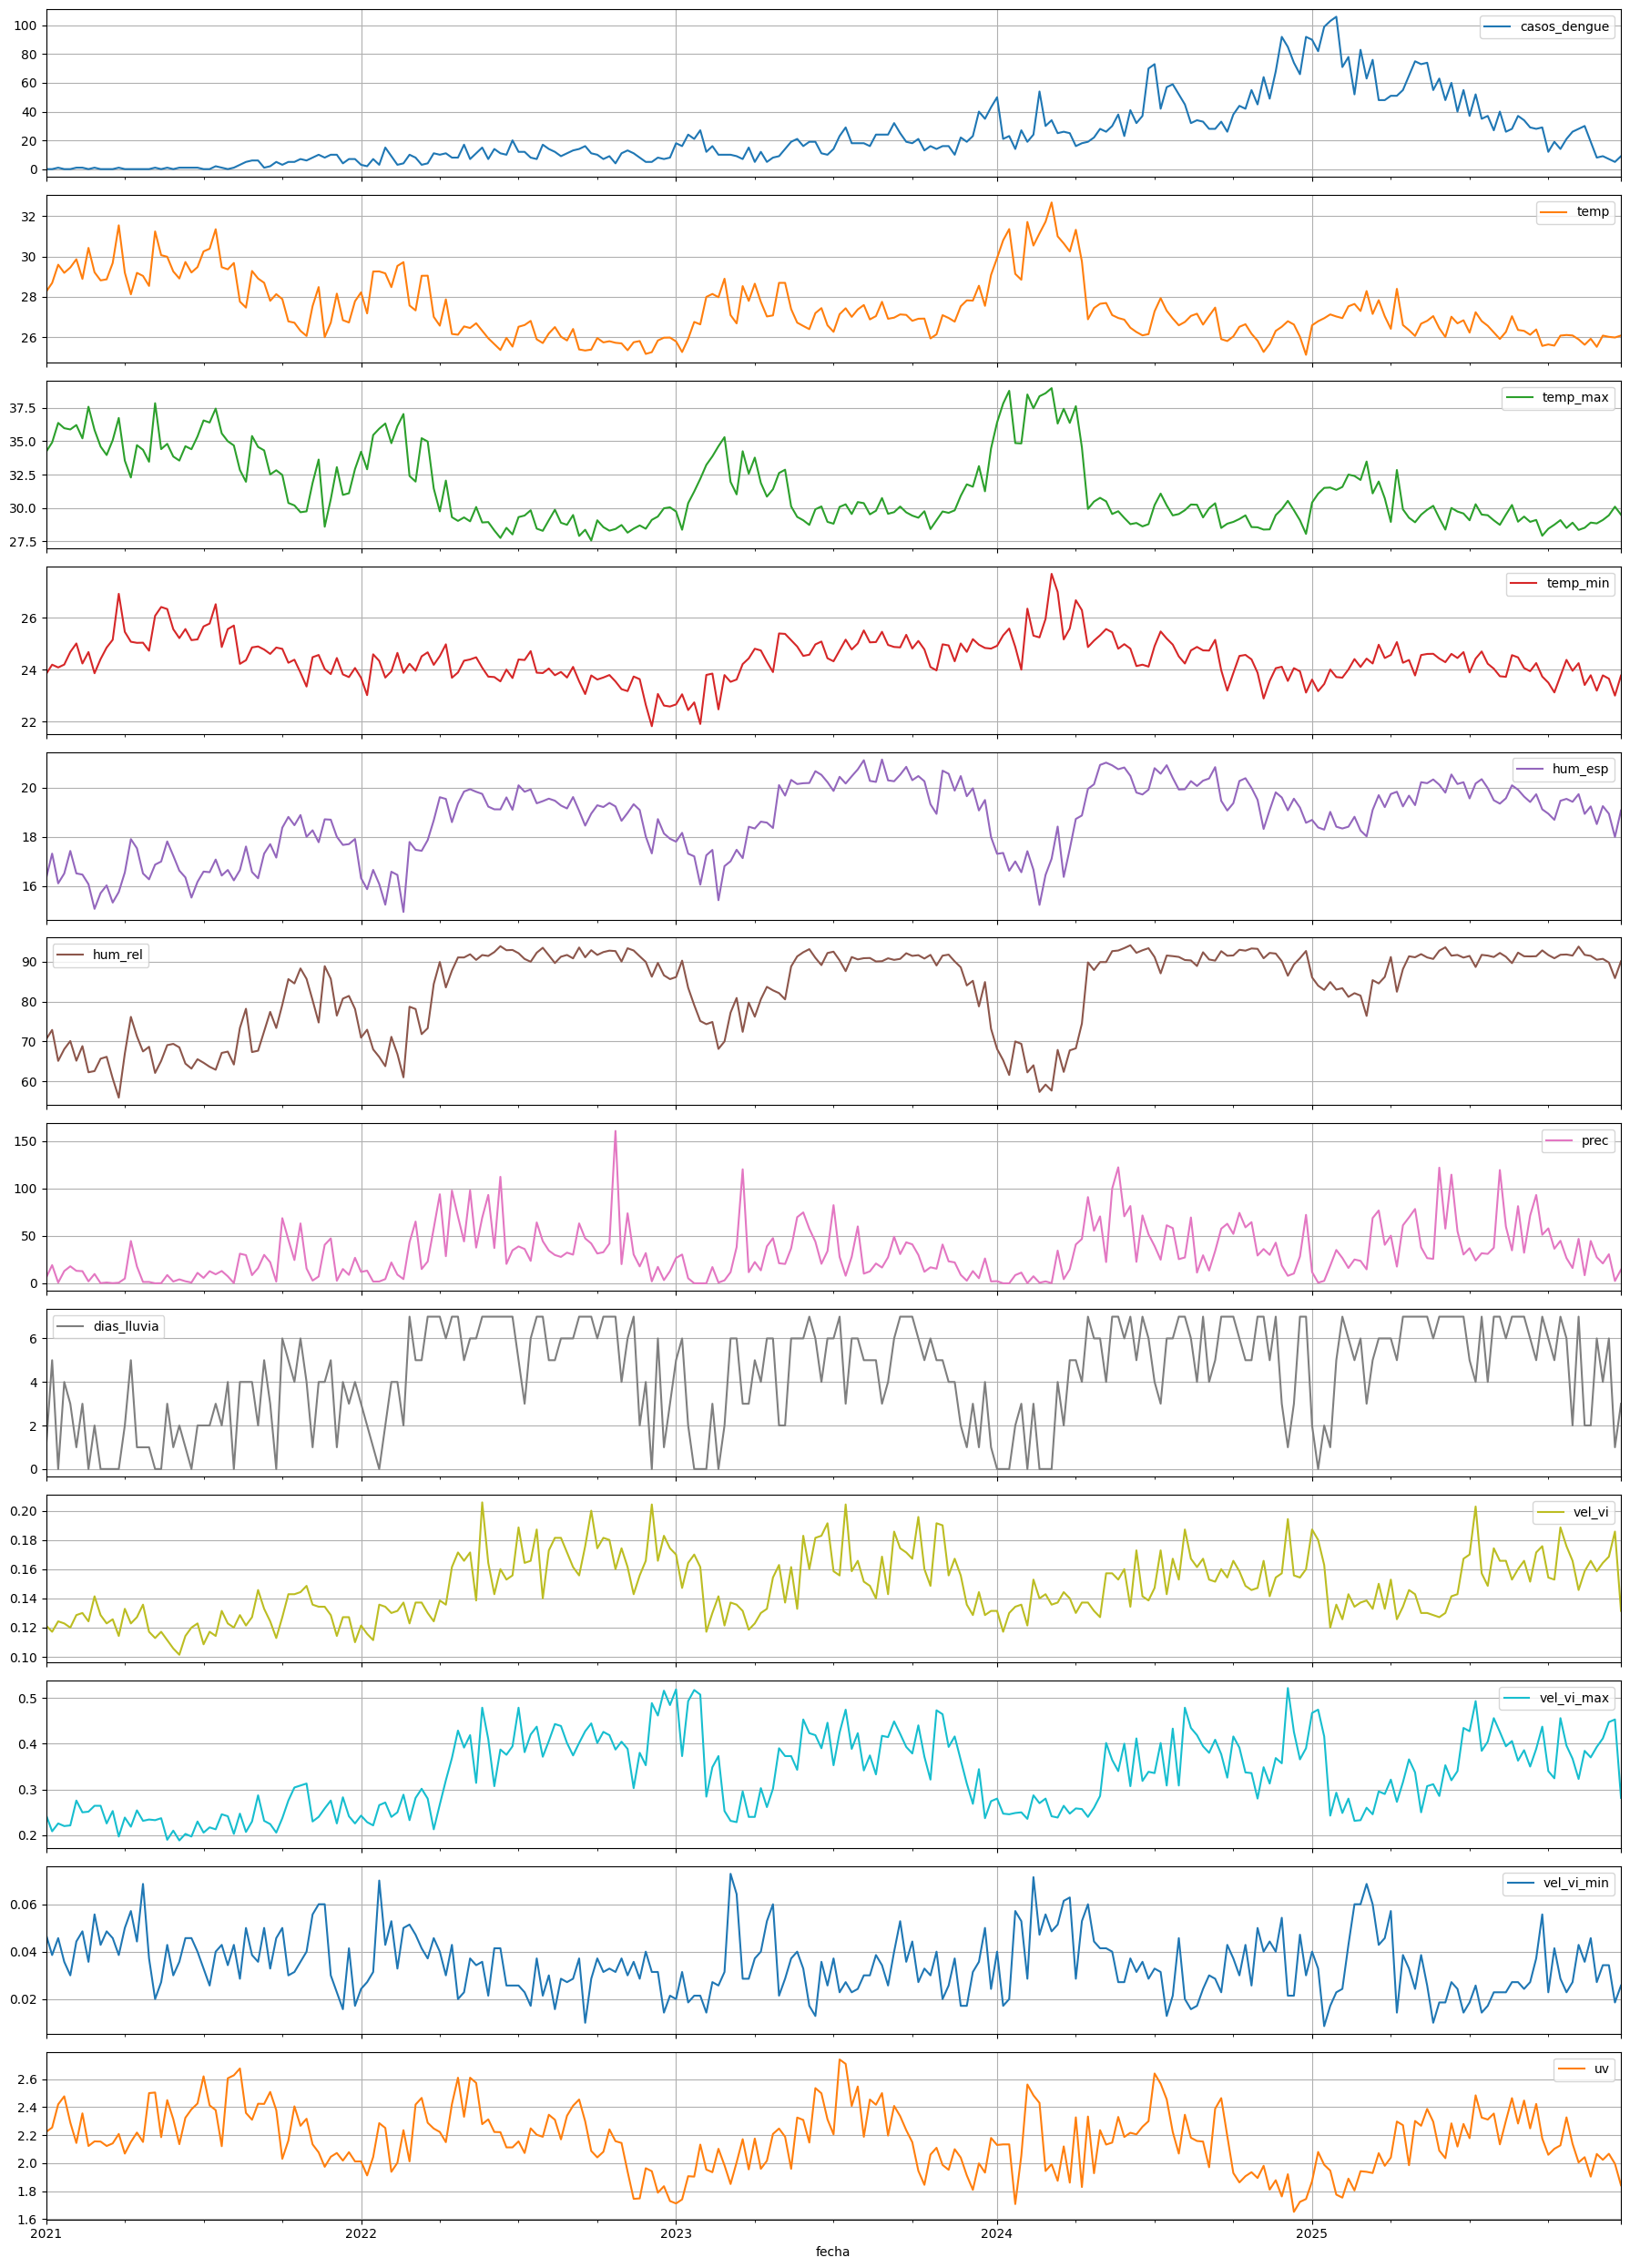

In [ ]:
import matplotlib.pyplot as plt

axes = df_fusionado[['casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv']].plot(
    subplots=True,
    figsize=(18, 25)
)

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.title("Series temporales de las variables meteorológicas y epidemiológicas")
plt.savefig("series_temporales_imagen_.png") 
plt.show()


# Interpretación de estas series temporales 

Busca:

* temporadas lluviosas
* ciclos climáticos
* anomalías.

---



# 4. Distribución estadística

Esto ayuda a decidir transformaciones para ARIMA.



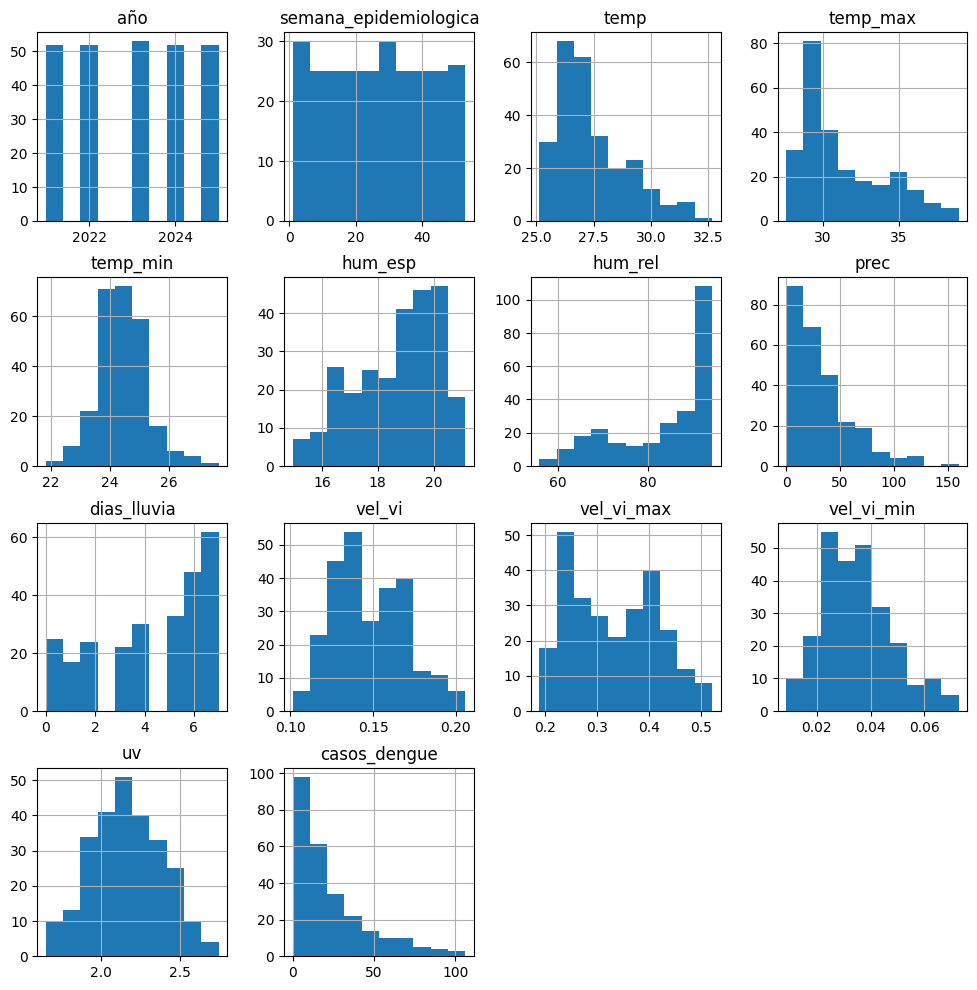

In [7]:
df_fusionado.hist(figsize=(12,12))
plt.title("Histogramas de las variables meteorológicas y epidemiológicas")
plt.savefig("histogramas.png")
plt.show()

# Interpertación de la matriz de histogramas 

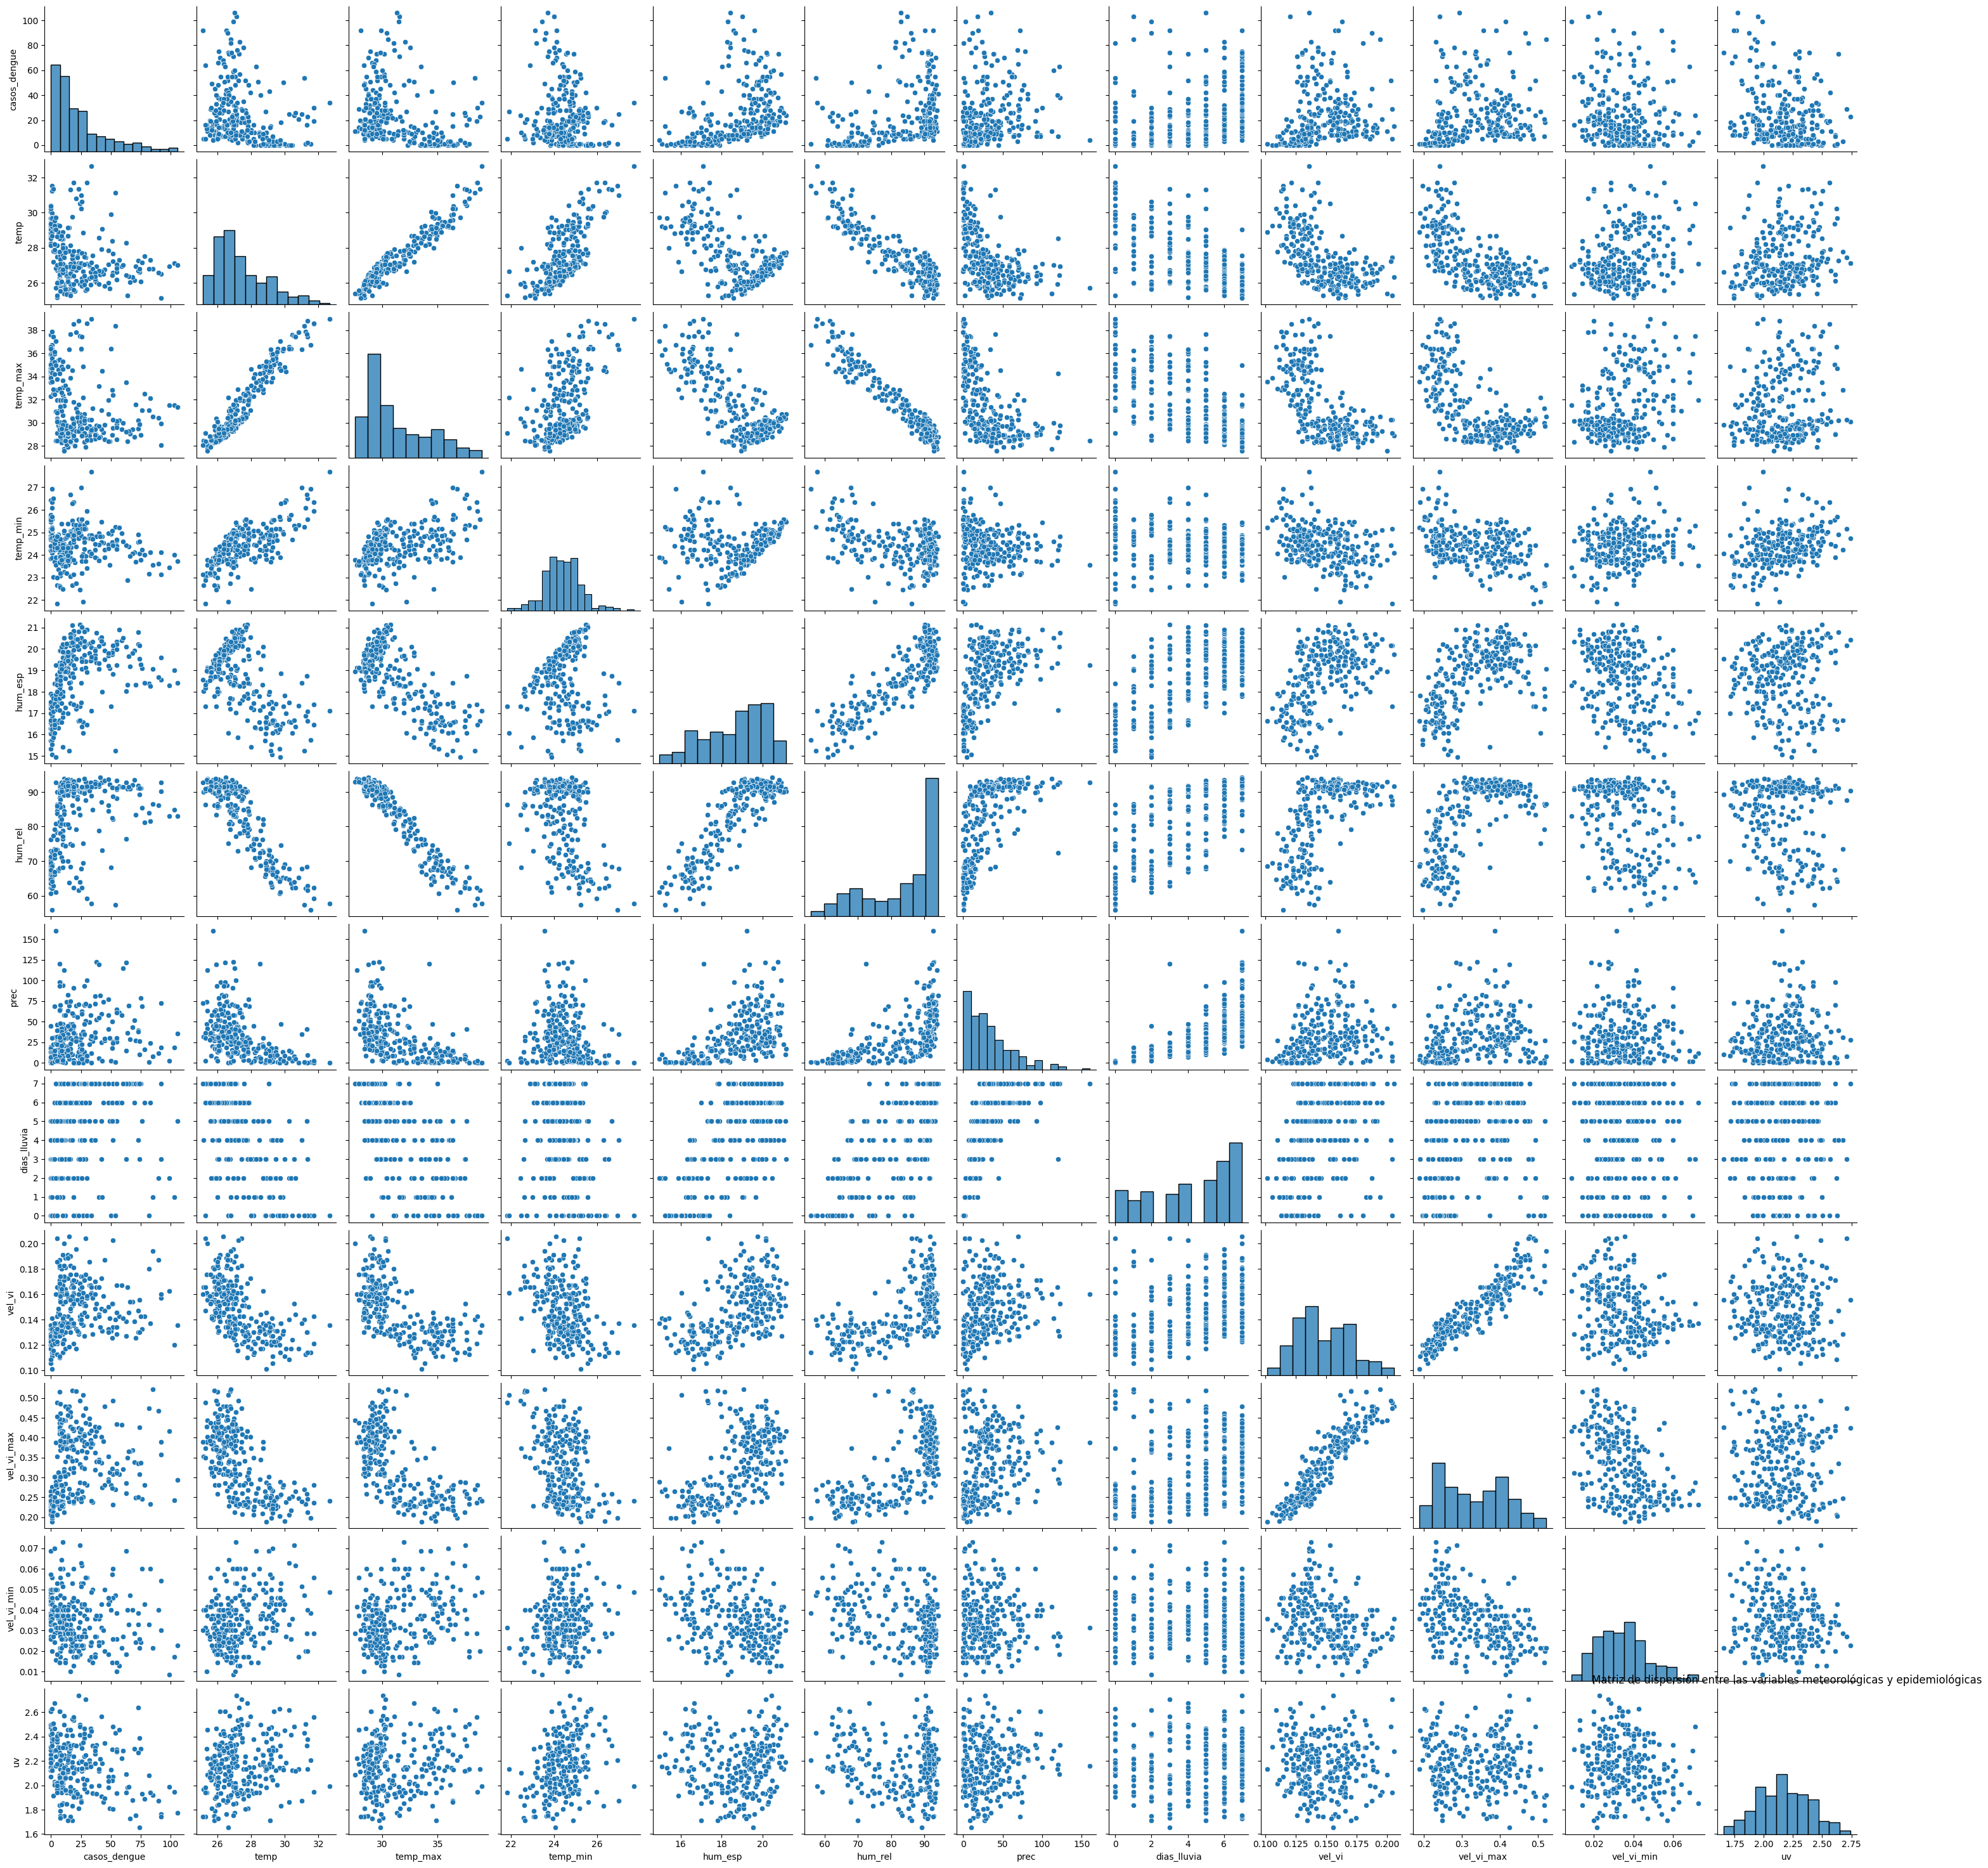

In [8]:
# graficar en una matriz todos los scaterter plots entre las variables numéricas
import seaborn as sns   
sns.pairplot(df_fusionado[['casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv']])
plt.title("Matriz de dispersión entre las variables meteorológicas y epidemiológicas")
plt.savefig("scatter_matrix.png")
plt.show()

# Interpretación de la matriz de diagramas de dispersión. 


Especial atención a:

* `casos_dengue`
* `prec`

Muchas veces requieren **log-transform**.

---



# 5. Correlación simple

Primer vistazo a relaciones clima–dengue.



<Axes: title={'center': 'Mapa de calor de la correlación entre las variables meteorológicas y epidemiológicas'}>

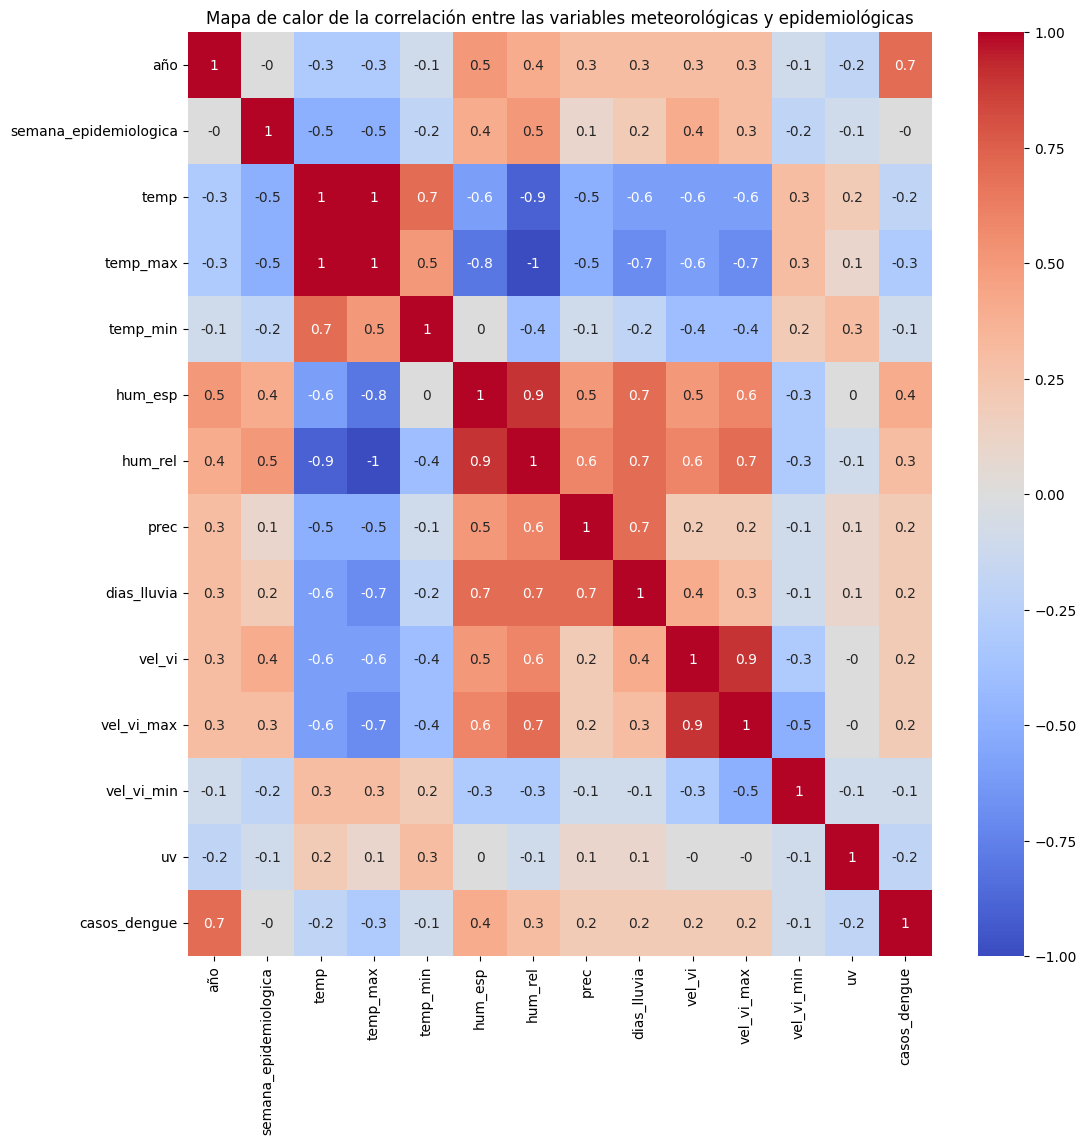

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,12))
plt.title("Mapa de calor de la correlación lineal o de Pearson entre las variables meteorológicas y epidemiológicas")
sns.heatmap(df_fusionado.corr(method='pearson').round(1), annot=True, cmap="coolwarm")


Observa si:

* lluvia
* humedad
* temperatura

tienen asociación.

---



# 6. Relación visual clima – dengue



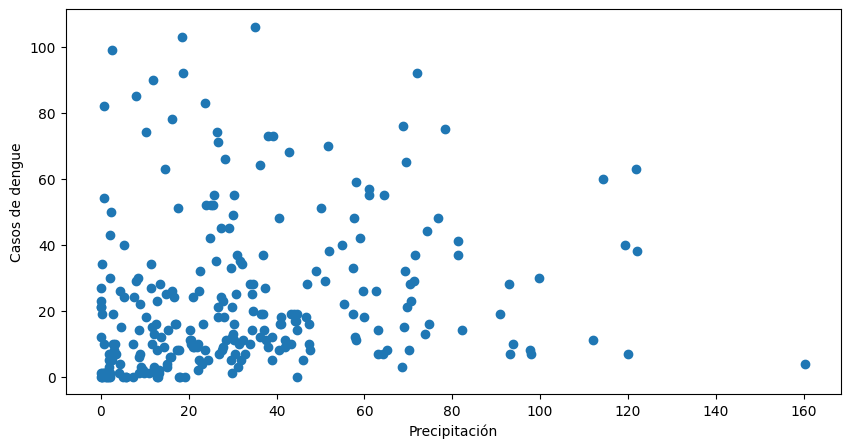

In [11]:
plt.figure(figsize=(10,5))

plt.scatter(df_fusionado["prec"], df_fusionado["casos_dengue"])

plt.xlabel("Precipitación")
plt.ylabel("Casos de dengue")

plt.savefig("scatter_prec_casos.png")
plt.show()


# Interpretación del scatter anterior. 

# 7. Estacionalidad epidemiológica

Muy importante para dengue.



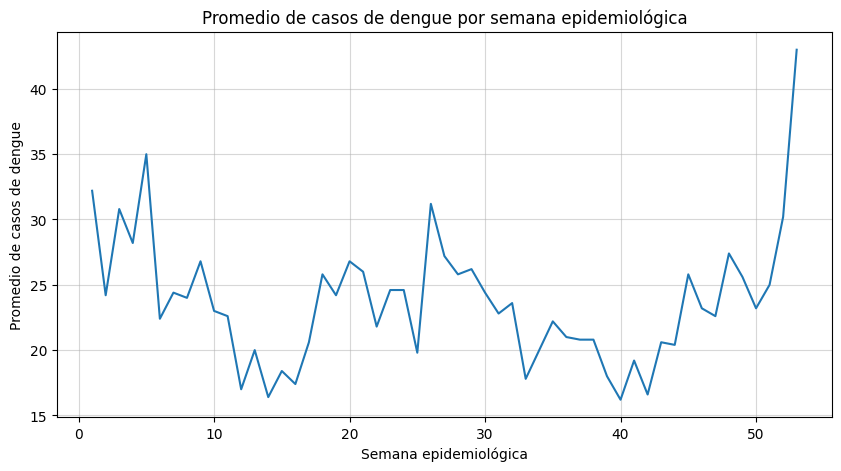

In [9]:
df_fusionado.groupby("semana_epidemiologica")["casos_dengue"].mean().plot(figsize=(10,5))
plt.xlabel("Semana epidemiológica")
plt.ylabel("Promedio de casos de dengue")
plt.title("Promedio de casos de dengue por semana epidemiológica")
plt.grid(alpha=0.5) 


Esto muestra:

* semanas de mayor riesgo
* patrón anual.

---


# Adicionar al dataset los atributos meteorológicos rezagados un un rezago hasta 12. 

In [14]:
df_fusionado.columns

Index(['año', 'semana_epidemiologica', 'temp', 'temp_max', 'temp_min',
       'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max',
       'vel_vi_min', 'uv', 'casos_dengue'],
      dtype='str')

In [16]:
# Lista de variables meteorológicas
variables_meteo = ['temp', 'temp_max', 'temp_min',
       'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max',
       'vel_vi_min', 'uv'
]

# Número máximo de rezagos
max_lag = 12

# Generar rezagos
for var in variables_meteo:
    for lag in range(1, max_lag + 1):
        df_fusionado[f"{var}_lag_{lag}"] = df_fusionado[var].shift(lag)

# Ver resultado
df_fusionado.head(15)

,año,semana_epidemiologica,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,uv_lag_3,uv_lag_4,uv_lag_5,uv_lag_6,uv_lag_7,uv_lag_8,uv_lag_9,uv_lag_10,uv_lag_11,uv_lag_12
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-10,2021,2,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-17,2021,3,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-24,2021,4,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,...,2.222857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-31,2021,5,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,...,2.254286,2.222857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-07,2021,6,29.862857,36.214286,25.011429,16.515714,65.161429,13.17,1,0.128571,...,2.420000,2.254286,2.222857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-14,2021,7,28.888571,35.214286,24.241429,16.468571,68.828571,12.80,3,0.130000,...,2.477143,2.420000,2.254286,2.222857,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-21,2021,8,30.425714,37.588571,24.681429,16.080000,62.268571,2.09,0,0.124286,...,2.290000,2.477143,2.420000,2.254286,2.222857,NaN,NaN,NaN,NaN,NaN
2021-02-28,2021,9,29.217143,35.844286,23.867143,15.078571,62.567143,9.83,2,0.141429,...,2.144286,2.290000,2.477143,2.420000,2.254286,2.222857,NaN,NaN,NaN,NaN


In [17]:
df_fusionado_y_rezagado  = df_fusionado
df_fusionado_y_rezagado.head(2)

,año,semana_epidemiologica,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,uv_lag_3,uv_lag_4,uv_lag_5,uv_lag_6,uv_lag_7,uv_lag_8,uv_lag_9,uv_lag_10,uv_lag_11,uv_lag_12
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.252857,34.20,23.832857,16.308571,70.508571,5.72,1,0.121429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-10,2021,2,28.687143,34.91,24.195714,17.318571,72.885714,19.15,5,0.117143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_fusionado_y_rezagado.to_excel(r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\3_base_datos_consolidada\datos_fusionados_y_rezagados.xlsx", index = False)

# Visualización gráfica de el dataset con atributos meteorológicos rezagados. 

### Visualización clave:

* Superposición:

  * casos (t)
  * precipitación $t - k$
Una matriz por cada atributo meteorológicos de scatter. 

Para varios valores de $ k $

- Esto prepara al estudiante para interpretar causalidad temporal



## 4. Exploración masiva de rezagos (núcleo del análisis)

Aquí tienes muchas variables → necesitas sintetizar

---



### 🔸 4.1 Matriz de correlación con rezagos

- Construye:

* correlación entre:

  * casos
  * todas las variables `*_lag_k`

### Visualización:

* Heatmap

- Pregunta:

> ¿Qué variable y qué rezago explican mejor los casos?

---



### 🔸 4.2 Curvas de correlación por rezago

Para cada variable meteorológica:

* eje x → rezago (1 a 12)
* eje y → correlación con casos

- Una curva por variable

- Pregunta:

> ¿En qué semana el efecto es máximo?

---



## 5. Visualización bivariada (relación directa)

Una vez identificado el mejor rezago:

### Visualizaciones:

* Scatter plot:

  * precipitación_lag_k vs casos
* Con línea de tendencia

- Pregunta:

> ¿La relación es lineal, no lineal, débil o fuerte?

---



## 6. Análisis temporal con rezago óptimo

Aquí integras lo aprendido:

### Visualización:

* Serie temporal combinada:

  * casos (t)
  * variable_lag_k (alineada correctamente)

- Pregunta:

> ¿El patrón climático anticipa los brotes?

---

## 🔹 7. Segmentación (si aplica)

Puedes enriquecer con:

* Por año
* Por temporada (seca vs lluviosa)
* Por región

👉 Visualizaciones:

* subplots
* dashboards con filtros

---

## 🔹 8. Síntesis en dashboard (nivel final)

Aquí condensas TODO:

---

### 📊 Componentes mínimos

1. **KPIs**
2. **Serie temporal de casos**
3. **Heatmap de correlación**
4. **Curva de rezagos**
5. **Scatter del mejor modelo**
6. **Filtro por variable meteorológica**

---

### 🛠 Herramientas ideales

* Plotly
* Dash

---

## 🔹 9. Interpretación científica

Aquí es donde realmente aportas valor:

* Detectar:

  * rezagos significativos
  * estacionalidad
* Formular hipótesis:

  * reproducción del mosquito
  * acumulación de agua
* Advertencia clave:

  > correlación ≠ causalidad

---

# 🧩 🧠 Esquema general del proceso

```id="pipeline_dengue"
Casos → Clima → Rezagos → Correlaciones → Mejor lag → Relación → Visualización → Interpretación
```

---

# 🚀 Enfoque pedagógico (muy alineado contigo)

Puedes convertir esto en una actividad:

### Problema central:

> “Identifique el rezago climático que mejor explica el comportamiento del dengue”

### Habilidades que desarrollas:

* pensamiento computacional
* análisis de datos
* modelación temporal
* interpretación científica

---

# 💡 Idea avanzada (para investigación o publicación)

Puedes extender a:

* modelos predictivos con rezagos
* regresión múltiple
* machine learning

Pero el **dashboard es la base para justificar el modelo**





# 8. Análisis de rezagos climáticos (clave para ARIMAX)

El mosquito responde con retraso.


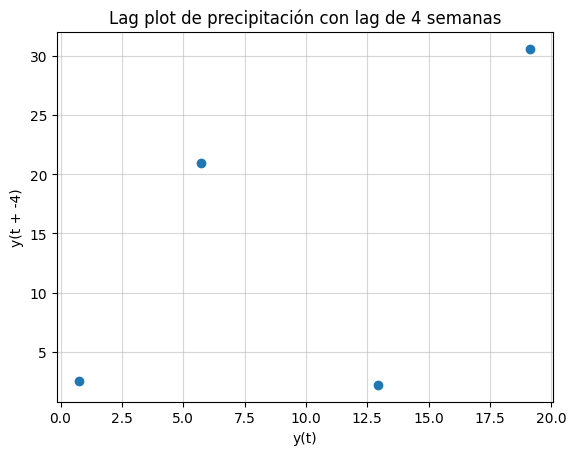

In [ ]:
# Graficar casos de dengue contra cada atributo meteorolóco rezagados 
from pandas.plotting import lag_plot

lag_plot(df_fusionado["prec"], lag=-4)
plt.title("Lag plot de precipitación con lag de 4 semanas")
plt.savefig("lag_plot_prec.png")
plt.grid(alpha=0.5)
plt.show()


También:



In [15]:
df_fusionado.columns 
atributos_meteorologicos = [ 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv']

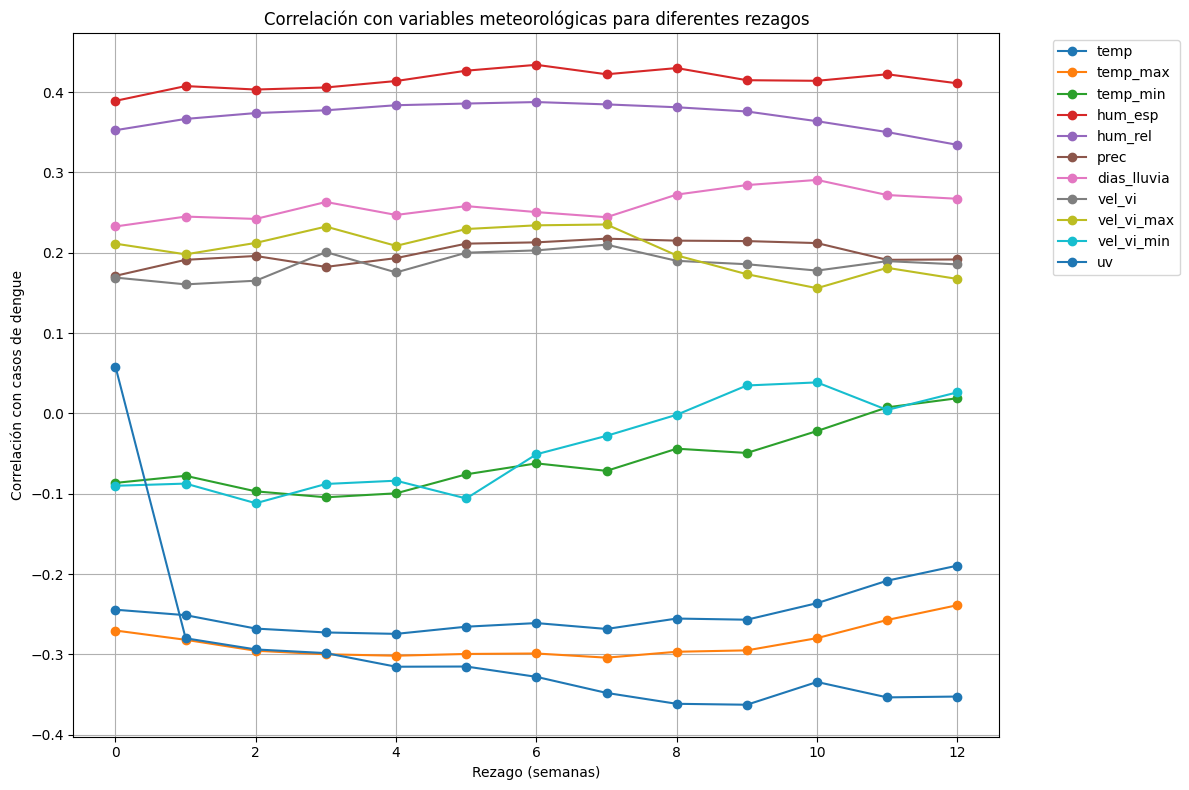

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variables meteorológicas
variables_meteo = [
    'temp', 'temp_max', 'temp_min',
    'hum_esp', 'hum_rel',
    'prec', 'dias_lluvia',
    'vel_vi', 'vel_vi_max', 'vel_vi_min',
    'uv'
]

# Número máximo de rezagos
max_lag = 12

# DataFrame para guardar resultados
corr_lags = pd.DataFrame(index=range(max_lag + 1), columns=variables_meteo)

# Cálculo de correlaciones
for var in variables_meteo:
    
    for lag in range(max_lag + 1):
        
        corr = df_fusionado['casos_dengue'].corr(
            df_fusionado[var].shift(lag)
        )
        
        corr_lags.loc[lag, var] = corr

# Convertir a float
corr_lags = corr_lags.astype(float)

# ---------- GRAFICO ----------

plt.figure(figsize=(12,8))

for var in variables_meteo:
    plt.plot(corr_lags.index, corr_lags[var], marker='o', label=var)

plt.xlabel('Rezago (semanas)')
plt.ylabel('Correlación con casos de dengue')
plt.title('Correlación con variables meteorológicas para diferentes rezagos')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.savefig("correlacion_rezagos.png")
plt.show()



Muchos estudios encuentran retrasos de:

* 2 semanas
* 4 semanas
* 8 semanas.

---



# 9. Descomposición de la serie

Esto ayuda a ver:

* tendencia
* estacionalidad
* ruido.

```python


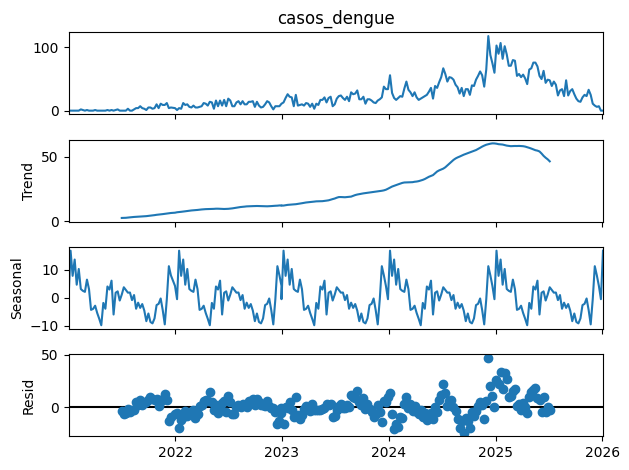

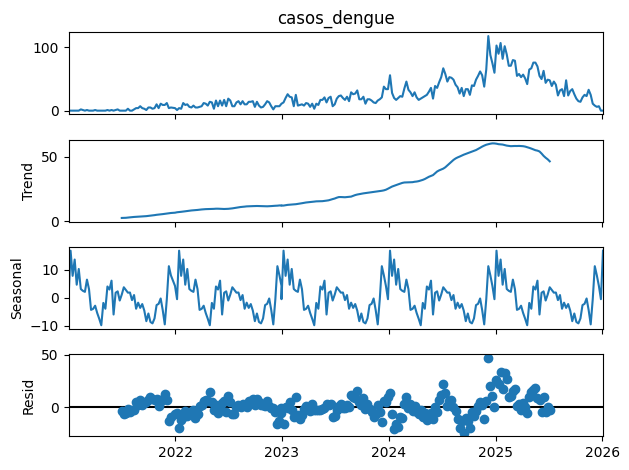

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_fusionado["casos_dengue"], model="additive", period=52)

decomp.plot()



# 10. Identificación preliminar para ARIMA

Antes de modelar:



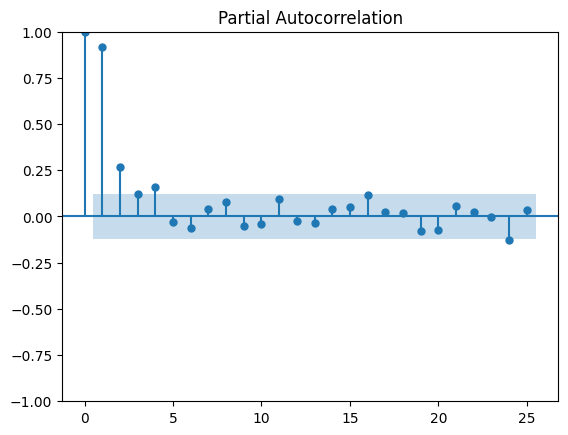

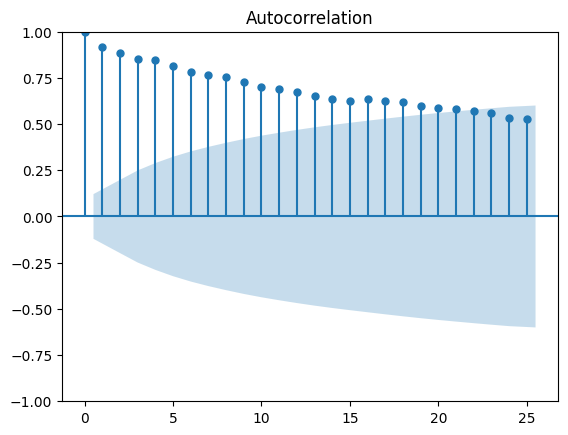

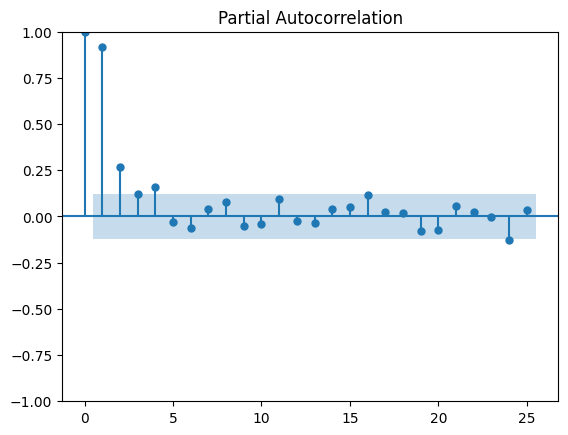

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_fusionado["casos_dengue"])
plot_pacf(df_fusionado["casos_dengue"])



Esto orienta:

* orden AR
* orden MA
* necesidad de diferenciación.

---



# Cómo dejar esta etapa metodológicamente sólida (para un paper)

Puedes estructurar tu notebook así:

```
1_descripcion_datos
2_visualizacion_series
3_estacionalidad
4_relaciones_climaticas
5_lags_climaticos
6_diagnostico_series
```

---



# Algo importante para tu investigación

Muchos artículos fallan porque no revisan **correlación cruzada con rezagos**.

Ese análisis suele revelar cosas como:

```
lluvia  → aumento dengue 3 a 6 semanas después
```

Esto es exactamente lo que necesitas para **ARIMAX epidemiológico**.

---


# Tarea: 

Buscar y configurar el análisis exploratorio de datos en un solo dashboard 

Condensar todo tu **análisis exploratorio de datos (EDA)** en un solo dashboard en Python no es solo “pegar gráficas”, sino **organizar una narrativa visual** donde cada elemento responde a una pregunta clave. Te explico cómo hacerlo de forma clara y aplicable a tus clases y proyectos.

---



# 1. Cambia el enfoque: de EDA → historia analítica

Antes de programar, define:

- ¿Qué preguntas responde tu dashboard?

Por ejemplo:

* ¿Cómo se comportan las variables principales?
* ¿Hay relaciones importantes?
* ¿Existen outliers o patrones temporales?
* ¿Qué decisiones se pueden tomar?

- Regla clave:
**Un dashboard NO muestra todo el EDA, solo lo esencial.**

---



# 2. Estructura ideal de un dashboard (muy didáctica)

Puedes organizarlo en 4 bloques:

## (1) Resumen general (KPIs)

* Media
* Mediana
* Desviación estándar
* Número de registros

 Esto reemplaza `df.describe()`

---

## (2) Distribuciones

* Histogramas
* Boxplots

- Responde: *¿cómo se comporta cada variable?*

---



## (3) Relaciones

* Scatter plots
* Matriz de correlación

- Responde: *¿qué variables están relacionadas?*

---

## 🔹 (4) Segmentación / filtros

* Por categoría
* Por tiempo
* Por grupo

- Aquí entra la **interactividad**

---



# 3. Herramienta recomendada

La mejor opción para lo que haces es:

- Dash + Plotly

Porque:

* Es 100% Python
* Interactivo
* Perfecto para docencia y proyectos

---



# 4. Ejemplo mínimo (estructura completa)

Este ejemplo condensa un EDA en un solo dashboard:



In [ ]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# Datos
df = pd.read_excel(r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\3_base_datos_consolidada\datos_fusionados_y_rezagados.xlsx")

app = Dash(__name__)

app.layout = html.Div([
    
    html.H1("Dashboard de Análisis Exploratorio"),

    # Filtro
    dcc.Dropdown(
        options=[{"label": col, "value": col} for col in df.columns if df[col].dtype != 'object'],
        value=df.select_dtypes(include='number').columns[0],
        id='variable'
    ),

    # KPIs
    html.Div(id="kpis"),

    # Gráficos
    dcc.Graph(id="histograma"),
    dcc.Graph(id="boxplot"),
    dcc.Graph(id="scatter"),
])

@app.callback(
    [Output("kpis", "children"),
     Output("histograma", "figure"),
     Output("boxplot", "figure"),
     Output("scatter", "figure")],
    [Input("variable", "value")]
)
def actualizar(variable):

    media = df[variable].mean()
    std = df[variable].std()

    kpis = html.Div([
        html.H3(f"Media: {media:.2f}"),
        html.H3(f"Desviación estándar: {std:.2f}")
    ])

    hist = px.histogram(df, x=variable, title="Distribución")
    box = px.box(df, y=variable, title="Boxplot")

    # relación con otra variable numérica
    otra = df.select_dtypes(include='number').columns[1]
    scatter = px.scatter(df, x=variable, y=otra, title="Relación")

    return kpis, hist, box, scatter

if __name__ == "__main__":
    app.run(debug=True)



# 5. Estrategia de condensación (clave para ti como docente)

Cuando pases de EDA → dashboard, aplica esta tabla mental:

| EDA tradicional       | Dashboard          |
| --------------------- | ------------------ |
| `df.describe()`       | KPIs               |
| Histogramas múltiples | Selector dinámico  |
| Muchas gráficas       | 3–5 gráficas clave |
| Código visible        | Interfaz limpia    |
| Análisis secuencial   | Vista simultánea   |

---



#  6. Truco avanzado (muy potente en clase)

Organiza tu dashboard como si fuera una clase:

1. **Contexto (título)**
2. **Exploración (distribución)**
3. **Relaciones**
4. **Conclusión visual**

- Esto conecta perfecto con tu enfoque de:

* aula invertida
* pensamiento computacional
* interpretación de datos

---



# 7. Idea para tu curso (muy alineada contigo)

Pide a tus estudiantes:

> “Transforme su EDA en un dashboard donde cada gráfico responda una pregunta”

Eso desarrolla:

* síntesis
* modelación
* pensamiento crítico

---
